In [ ]:
# Author: Alberto Fernández Comesaña

import os
import pandas as pd
import matplotlib.pyplot as plt

import utils
from sklearn.model_selection import cross_val_score

In [6]:
DISCHARGES_DIR = os.path.join(os.pardir, 'discharges')
METEO_DIR = os.path.join(os.pardir, 'meteo-csv')

WEST_RIVERS = ("kopingsan", "hedstrommen", "arbogaan", "kolbacksan", "svartan", "eskilstunaan", "sagan", "enkopingsan", "rackstaan", "brobacken")
NORTH_RIVERS = ("fyrisan", "orsundaan", "savaan", "lovstaan", "marstaan", "oxundaan")

utils.load_river_data('../rivers-csv', groups={'north': NORTH_RIVERS, 'west': WEST_RIVERS})

,north,west
0,27.870908,178.842829
1,60.568181,257.862994
2,57.123295,305.479471
3,36.227415,248.452064
4,28.449762,201.523764
...,...,...
1291,7.501276,51.932814
1292,10.894536,58.434922
1293,26.529891,100.653294
1294,13.722663,89.893140


In [8]:
rivers, dicharges = utils.load_data(river_dir = '../rivers-csv', discharge_dir='../discharges', groups={'north': NORTH_RIVERS, 'west': WEST_RIVERS})

In [38]:
import re
# re.match(r'[]', 'west:kopingsan,hedstrommen;north:fyrisan,orsundaan,savaan')
print(re.match(r'^([A-Z],?)+$', 'A,B'))

<re.Match object; span=(0, 3), match='A,B'>


Mean cross validation: 0.2062


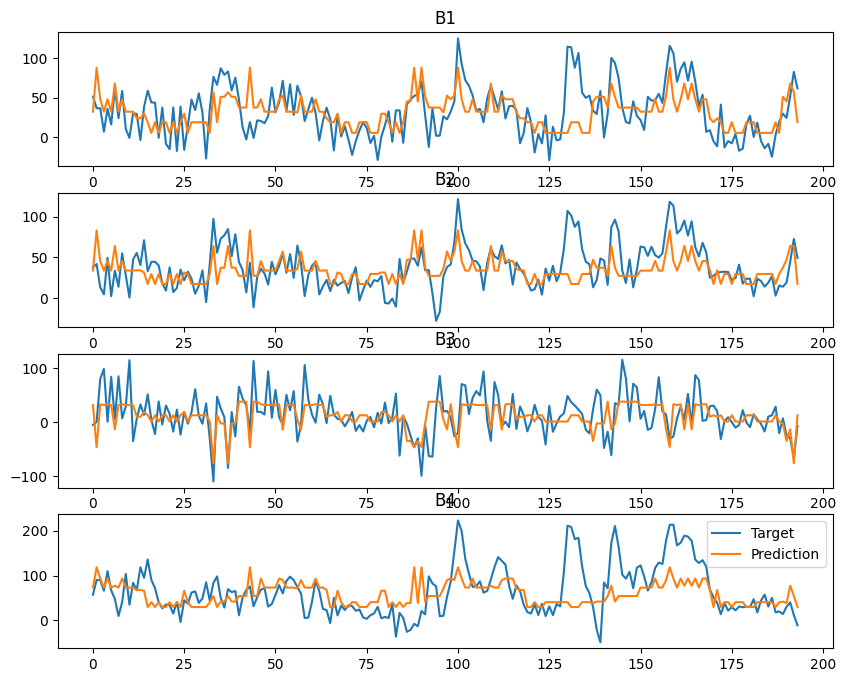

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=4)
cv_score = cross_val_score(tree_reg, X_train, Y_train, cv=10, scoring='r2').mean()
print(f'Mean cross validation: {cv_score:.4f}')

tree_reg.fit(X_train, Y_train)
Y_pred_tree_reg = tree_reg.predict(X_test)

utils.plot_predictions(Y_test, Y_pred_tree_reg)


Mean cross validation: 0.3713


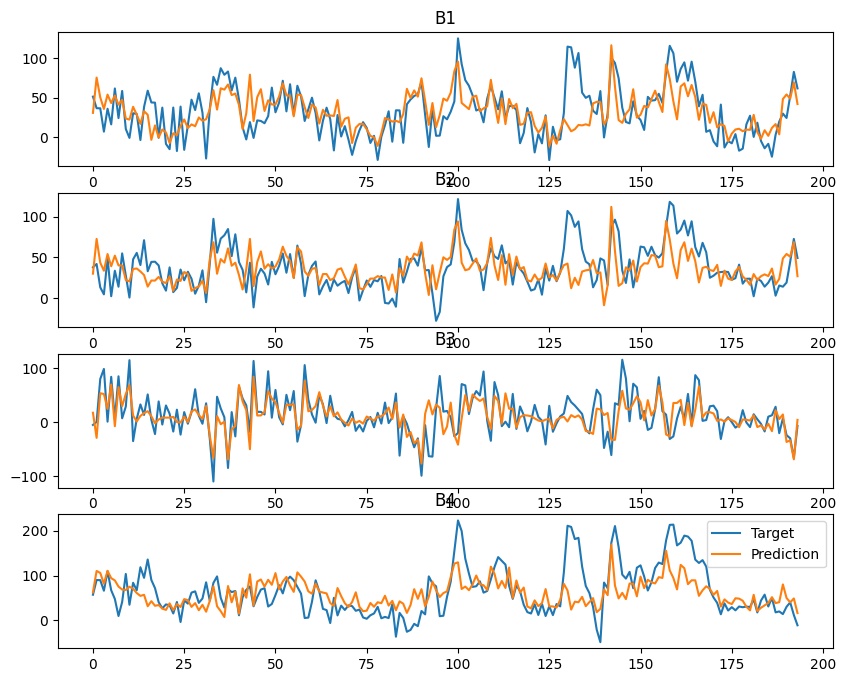

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100)
cv_score = cross_val_score(rf_reg, X_train, Y_train, cv=10, scoring='r2').mean()
print(f'Mean cross validation: {cv_score:.4f}')

rf_reg.fit(X_train, Y_train)
Y_pred_rf = rf_reg.predict(X_test)

utils.plot_predictions(Y_test, Y_pred_rf)